# Visualizing the spherical harmonics

The real spherical harmonics $Y_l^m(\theta, \varphi)$ form an orthonormal basis
on the sphere. This notebook constructs and plots them by applying the inverse SHT
to unit basis vectors in spectral space.

## Setup

In [1]:
import torch
import matplotlib.pyplot as plt

from torch_harmonics import RealSHT, InverseRealSHT
from torch_harmonics.plotting import plot_sphere

## Forming the Vandermonde matrix

The Vandermonde matrix maps spectral coefficients to grid values. Each column
corresponds to a single spherical harmonic $Y_l^m$. We construct it by applying
the ISHT to each canonical basis vector $e_{l,m}$ in the coefficient space.

For negative orders $m < 0$, the real spherical harmonics are recovered by placing
the basis vector in the imaginary part of the $|m|$ coefficient.

In [2]:
nlat = 60
nlon = 2*nlat
lmax = mmax = nlat

sht = RealSHT(nlat, nlon, lmax=lmax, mmax=mmax)
isht = InverseRealSHT(nlat, nlon, lmax=lmax, mmax=mmax)

In [3]:
# forming the Vandermonde matrix

nmodes = int(lmax * lmax)
e = torch.zeros(nmodes, lmax, mmax, dtype=torch.complex64)

midx = lambda l,m : l*(l+1) + m

for l in range(lmax):
    for m in range(-l, l+1):
        e[midx(l,m), l, abs(m)] = 1.0 if m >= 0 else 1.0j

vdm = isht(e)

## Plotting the spherical harmonics

We plot the first few spherical harmonics on a grid indexed by degree $l$ (rows)
and order $m$ (columns). Each subplot shows an orthographic projection of the sphere:

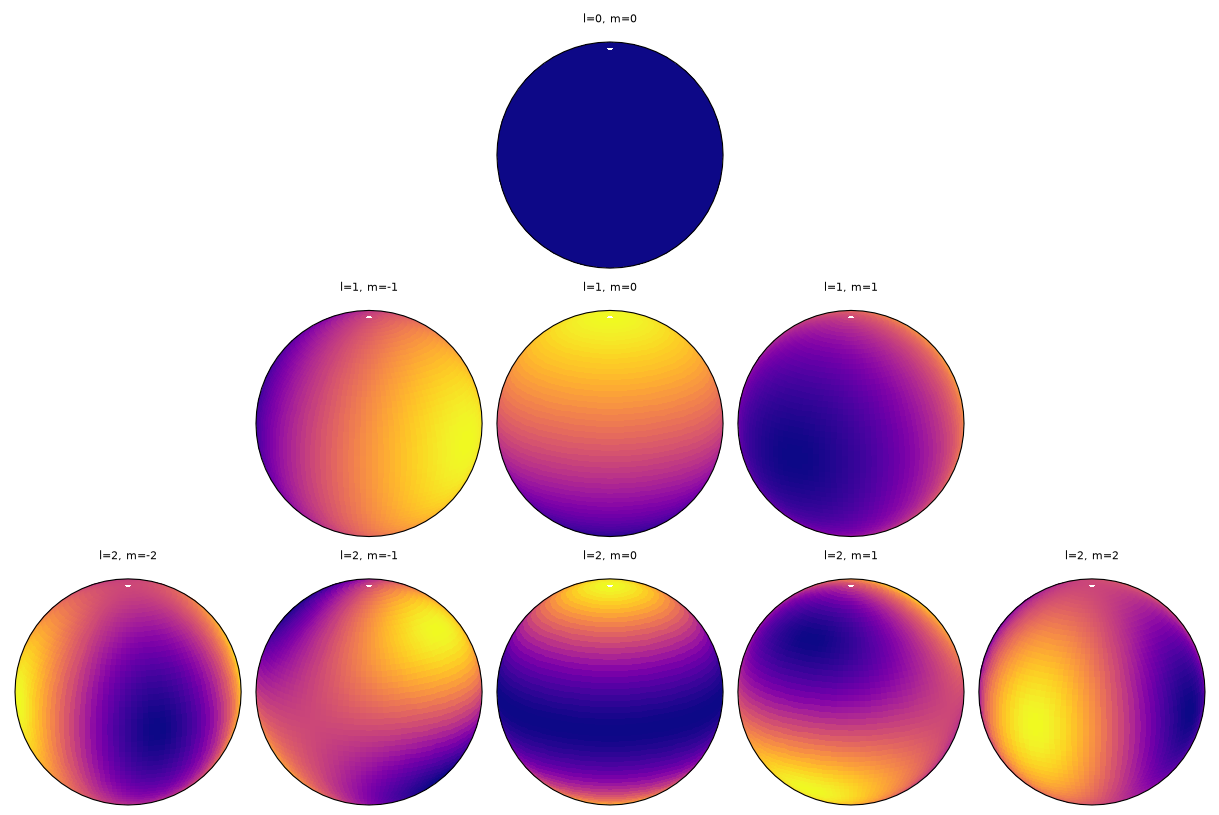

In [4]:
import os
os.makedirs("plots", exist_ok=True)

plt_lmax = 3

fig = plt.figure(layout='constrained', figsize=(12, 8))
subfigs = fig.subfigures(plt_lmax, 2*plt_lmax-1)

for l in range(plt_lmax):
    for m in range(-l, l+1):
        plot_sphere(vdm[midx(l,m)], fig=subfigs[l, m+plt_lmax-1], projection="orthographic", title=f"l={l}, m={m}", central_latitude=20, central_longitude=30, cmap="plasma")

plt.savefig("./plots/spherical_harmonics.png")

## Animated version (optional)

The following cells generate a rotating animation of the spherical harmonics.
Uncomment to run:

In [5]:
# import matplotlib.animation as animation

# fig = plt.figure(layout='constrained', figsize=(12, 8), dpi=72)
# subfigs = fig.subfigures(plt_lmax, plt_lmax)

# moviewriter = animation.writers['pillow'](fps=30)
# moviewriter.setup(fig, './plots/spherical_harmonics.gif', dpi=72)

In [6]:
# for frame in range(120):
#     # compute the rotation of the sphere
#     lon = -120 - 3 * frame

#     if frame % 10 == 0:
#         print(f"frame={frame}")

#     for l in range(plt_lmax):
#         for m in range(l+1):
#             plot_sphere(vdm[midx(l,m)], fig=subfigs[l, m], projection="orthographic", title=f"l={l}, m={m}", central_longitude=lon)

#     plt.draw()
#     moviewriter.grab_frame()

# moviewriter.finish()